In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
from  sklearn.datasets import make_regression

In [64]:
X, y = make_regression(n_samples= 10000, n_features= 9, n_informative= 9, n_targets= 1, noise= 40, random_state= 40)

In [65]:
df= pd.DataFrame(X)

In [66]:
df.head()

,0,1,2,3,4,5,6,7,8
0,0.659301,-0.873265,-1.131348,-1.536169,-0.389222,1.083696,-0.522184,-0.138940,0.582531
1,-0.710888,0.038088,-2.257872,0.471308,-0.785435,-1.206058,-0.181509,1.673171,-0.049688
2,-1.280161,-0.699849,0.267214,1.129680,-1.473343,1.283648,-0.586986,1.341152,0.829385
3,-0.192005,-0.386979,0.333613,-1.132213,1.147434,-0.394757,-1.142520,2.075169,-1.421046
4,1.138400,0.625220,0.219511,-0.916736,0.306517,-0.351486,1.748217,0.994541,-0.987304


In [67]:
column_names = [f'feature{i}' for i in range(1, 10)]
column_names

['feature1',
 'feature2',
 'feature3',
 'feature4',
 'feature5',
 'feature6',
 'feature7',
 'feature8',
 'feature9']

In [68]:
df.columns = column_names

In [69]:
df.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9
0,0.659301,-0.873265,-1.131348,-1.536169,-0.389222,1.083696,-0.522184,-0.138940,0.582531
1,-0.710888,0.038088,-2.257872,0.471308,-0.785435,-1.206058,-0.181509,1.673171,-0.049688
2,-1.280161,-0.699849,0.267214,1.129680,-1.473343,1.283648,-0.586986,1.341152,0.829385
3,-0.192005,-0.386979,0.333613,-1.132213,1.147434,-0.394757,-1.142520,2.075169,-1.421046
4,1.138400,0.625220,0.219511,-0.916736,0.306517,-0.351486,1.748217,0.994541,-0.987304


In [70]:
df['target'] = y

In [71]:
df.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,target
0,0.659301,-0.873265,-1.131348,-1.536169,-0.389222,1.083696,-0.522184,-0.138940,0.582531,-26.693130
1,-0.710888,0.038088,-2.257872,0.471308,-0.785435,-1.206058,-0.181509,1.673171,-0.049688,-392.958662
2,-1.280161,-0.699849,0.267214,1.129680,-1.473343,1.283648,-0.586986,1.341152,0.829385,7.949527
3,-0.192005,-0.386979,0.333613,-1.132213,1.147434,-0.394757,-1.142520,2.075169,-1.421046,-127.791905
4,1.138400,0.625220,0.219511,-0.916736,0.306517,-0.351486,1.748217,0.994541,-0.987304,68.250758


In [72]:
df.columns

Index(['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6',
       'feature7', 'feature8', 'feature9', 'target'],
      dtype='object')

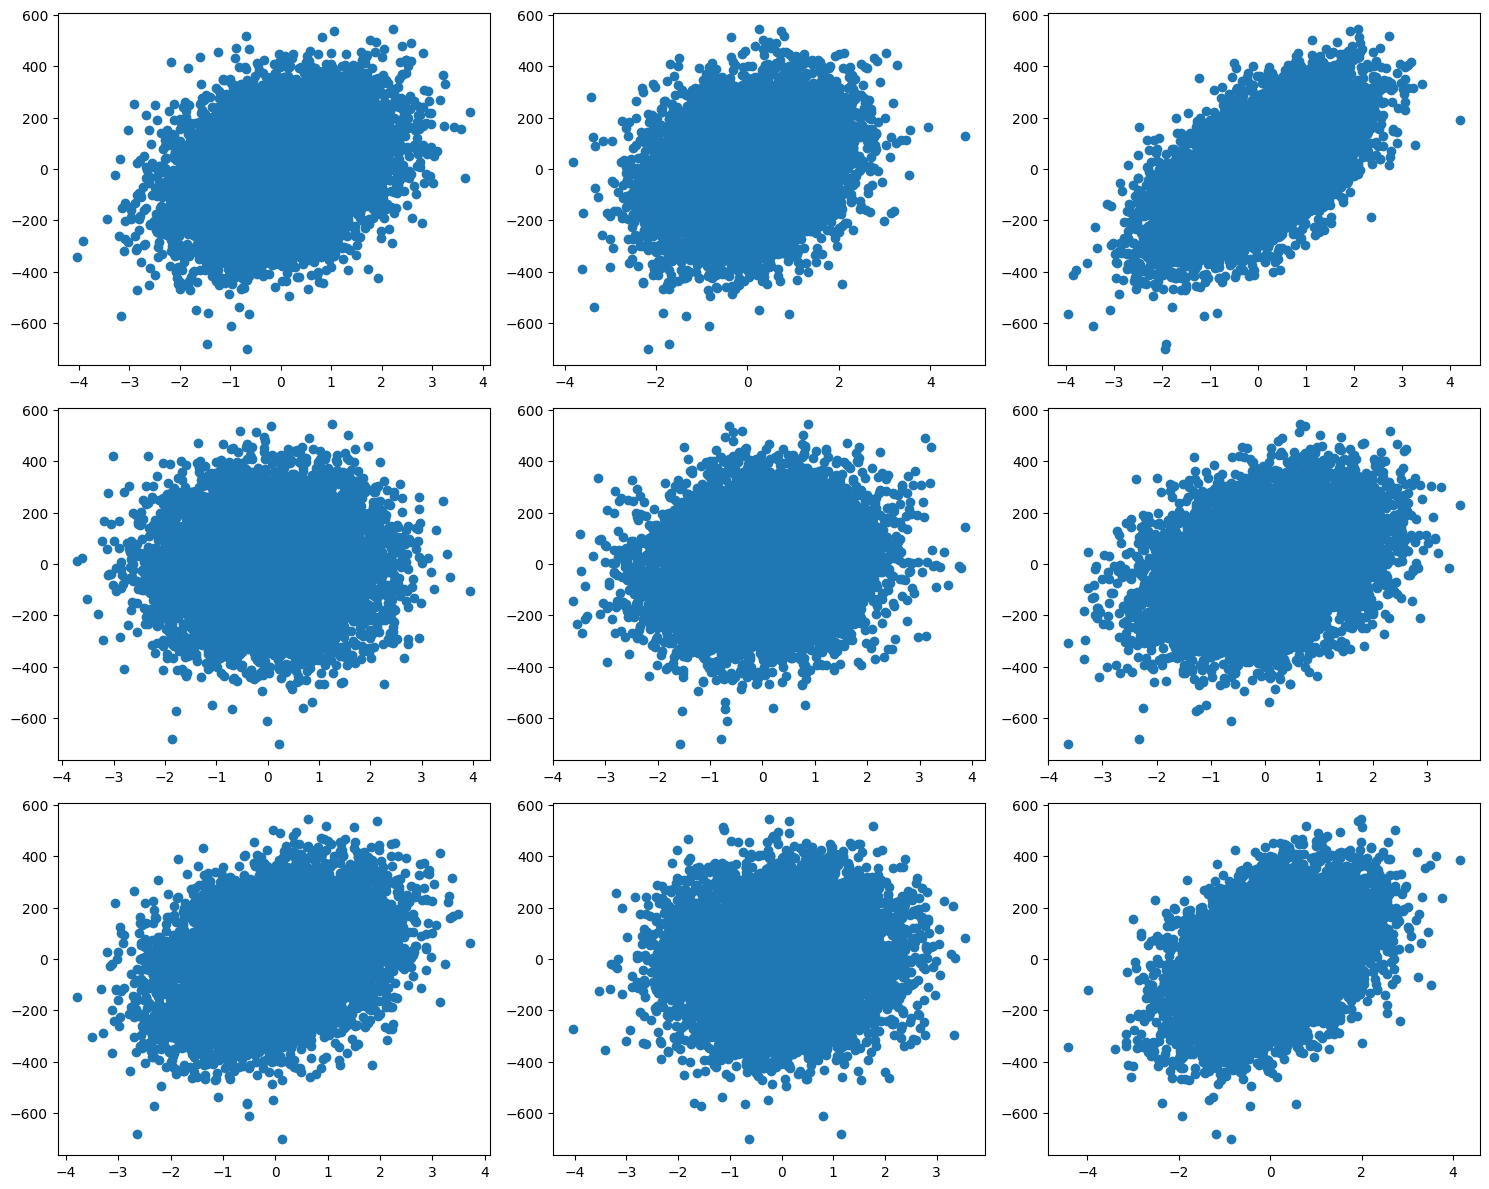

In [73]:
fig, ax = plt.subplots(3, 3, figsize = (15, 12))

for id,col in enumerate(df.columns[:-1]):
  row = id//3
  column = id%3
  ax[row, column].scatter(df[col], df['target'])
plt.tight_layout()
plt.show()

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 20)

In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
lr = LinearRegression()

In [78]:
lr.fit(X_train, y_train)

LinearRegression()

In [79]:
lr.coef_

array([48.50138263, 39.00566202, 99.52233752,  7.51782034, 17.74164602,
       54.0975804 , 51.44856856, 11.43331363, 63.4129615 ])

In [80]:
lr.intercept_

np.float64(0.4449550164944927)

In [81]:
y_pred = lr.predict(X_test)

In [82]:
from sklearn.metrics import r2_score

In [83]:
r2_score(y_test,y_pred)

0.9342522520250124

In [84]:
# OWN MLR class

In [85]:
class MLR():

  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self, X_train, y_train):
    X_train = np.insert(X_train, 0, 1, axis = 1)
    beta = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)
    self.intercept_ = beta[0]
    self.coef_ = beta[1:]
  def predict(self, X_test):
    return (np.dot(X_test, self.coef_) + self.intercept_)

In [86]:
lr2 = MLR()

In [87]:
lr2.fit(X_train, y_train)

In [88]:
lr2.coef_

array([48.50138263, 39.00566202, 99.52233752,  7.51782034, 17.74164602,
       54.0975804 , 51.44856856, 11.43331363, 63.4129615 ])

In [89]:
lr2.intercept_

np.float64(0.44495501649448976)

In [90]:
y_pred2 = lr2.predict(X_test)

In [91]:
r2_score(y_test, y_pred2)

0.9342522520250124